In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ── Battery specs ──────────────────────────────
CAPACITY_AH = 50        # Battery capacity in Ampere-hours (Ah)
V_NOMINAL   = 3.6       # Nominal voltage of one lithium-ion cell (Volts)
SOC_INIT    = 1.0       # Starting State of Charge (100% = fully charged)

# ── ECM Circuit parameters ─────────────────────
R0 = 0.01       # Internal resistance (Ohms)
R1 = 0.02       # Polarisation resistance (Ohms)
C1 = 2500.0     # Capacitance (Farads)

# ── Simulation time settings ───────────────────
DT          = 1         # Time step — 1 second per calculation
TOTAL_TIME  = 3600      # Total simulation time — 1 hour (in seconds)

In [3]:
# ── OCV Lookup Table ───────────────────────────────────────────
# Think of this as two columns of a spreadsheet:
# Left column  = SoC (0.0 means 0%, 1.0 means 100%)
# Right column = Voltage at that SoC level

# Column 1 — SoC values (0% to 100% in 10 steps)
SOC_POINTS = np.array([0.0,  # 0%   — completely empty
                        0.1,  # 10%
                        0.2,  # 20%
                        0.3,  # 30%
                        0.4,  # 40%
                        0.5,  # 50%  — half charged
                        0.6,  # 60%
                        0.7,  # 70%
                        0.8,  # 80%
                        0.9,  # 90%
                        1.0]) # 100% — fully charged

# Column 2 — Voltage at each SoC level (measured from real cells)
OCV_POINTS  = np.array([3.0,  # 0%   → 3.0V  (empty but not zero)
                         3.3,  # 10%  → 3.3V
                         3.5,  # 20%  → 3.5V
                         3.6,  # 30%  → 3.6V
                         3.65, # 40%  → 3.65V
                         3.7,  # 50%  → 3.7V  (halfway)
                         3.75, # 60%  → 3.75V
                         3.8,  # 70%  → 3.8V
                         3.9,  # 80%  → 3.9V
                         4.0,  # 90%  → 4.0V
                         4.2]) # 100% → 4.2V  (fully charged ceiling)

In [4]:
def get_ocv(soc):
    # soc is a number between 0.0 and 1.0
    # Example: soc = 0.75 means battery is 75% charged
    
    # np.interp does this:
    # "Find where 0.75 sits between my SOC_POINTS
    #  and return the matching voltage from OCV_POINTS"
    
    # It's like putting your finger on the table above
    # at 75% and reading across to find the voltage
    
    voltage = np.interp(soc, SOC_POINTS, OCV_POINTS)
    
    return voltage  # gives back the voltage for that SoC

In [5]:
# Let's manually test the function
print(f"At   0% SoC → {get_ocv(0.0)}V")   # should print 3.0
print(f"At  50% SoC → {get_ocv(0.5)}V")   # should print 3.7
print(f"At  75% SoC → {get_ocv(0.75)}V")  # should print 3.85
print(f"At 100% SoC → {get_ocv(1.0)}V")   # should print 4.2

At   0% SoC → 3.0V
At  50% SoC → 3.7V
At  75% SoC → 3.8499999999999996V
At 100% SoC → 4.2V


In [6]:
# ── Setup storage lists ────────────────────────────────
# These empty lists will collect results every second
time_log     = []   # stores each second: 0, 1, 2, 3...
voltage_log  = []   # stores voltage at each second
soc_log      = []   # stores SoC at each second
current_log  = []   # stores current at each second

# ── Starting conditions ────────────────────────────────
soc      = SOC_INIT   # start at 100% charged
i_r1     = 0.0        # no current flowing through R1 yet

# ── Define the load current ────────────────────────────
# We discharge at 25A constantly for the full hour
# (This is called a 0.5C discharge for a 50Ah battery)
I_LOAD = 25.0         # Amps (positive = discharging)

# ── The simulation loop ────────────────────────────────
for t in range(TOTAL_TIME):   # t goes from 0 to 3599

    # Step 1: Get OCV from current SoC
    ocv = get_ocv(soc)

    # Step 2: Update R1/C1 voltage (polarisation effect)
    # This models how voltage slowly recovers under load
    dv_r1 = (I_LOAD - i_r1) / C1  # rate of change
    i_r1  = i_r1 + dv_r1 * DT     # update every second

    # Step 3: Calculate terminal voltage
    # What a voltmeter would actually read at the battery terminals
    V_terminal = ocv - (I_LOAD * R0) - i_r1

    # Step 4: Update SoC using Coulomb counting
    # Every second we lose (current / capacity) worth of charge
    soc = soc - (I_LOAD * DT) / (CAPACITY_AH * 3600)
    soc = np.clip(soc, 0.0, 1.0)  # keep SoC between 0 and 1

    # Step 5: Log everything
    time_log.append(t)
    voltage_log.append(V_terminal)
    soc_log.append(soc * 100)      # convert to percentage
    current_log.append(I_LOAD)

print(f"Simulation complete — {len(time_log)} seconds simulated")
print(f"Final SoC:     {soc_log[-1]:.1f}%")
print(f"Final Voltage: {voltage_log[-1]:.3f}V")

Simulation complete — 3600 seconds simulated
Final SoC:     50.0%
Final Voltage: -15.628V


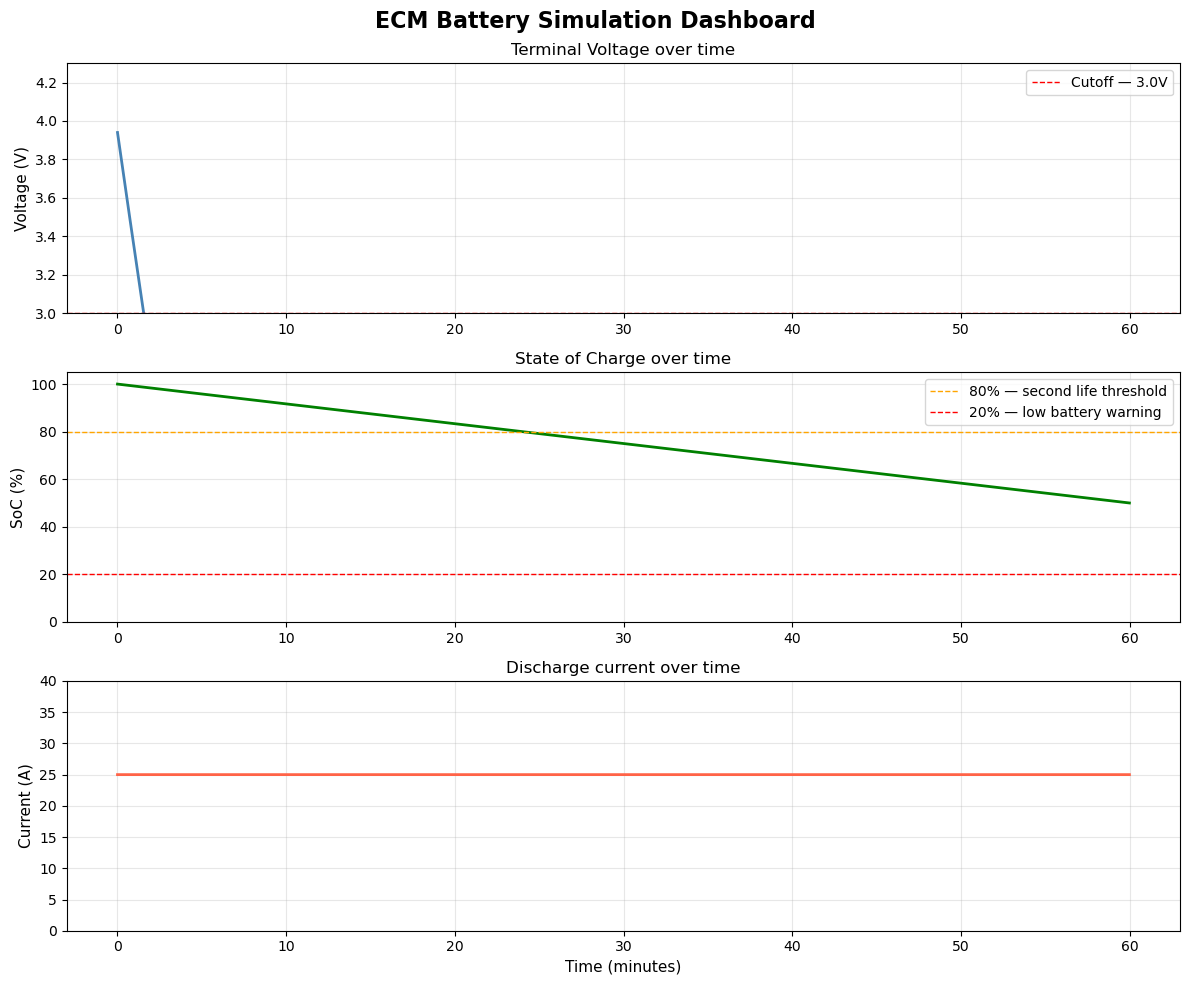

Dashboard saved as ecm_dashboard.png


In [7]:
# Convert logs to numpy arrays for easier plotting
time_arr    = np.array(time_log) / 60   # convert seconds to minutes
voltage_arr = np.array(voltage_log)
soc_arr     = np.array(soc_log)
current_arr = np.array(current_log)

# ── Create a 3 panel dashboard ─────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('ECM Battery Simulation Dashboard', fontsize=16, fontweight='bold')

# ── Panel 1 — Terminal Voltage ─────────────────────────
ax1.plot(time_arr, voltage_arr, color='steelblue', linewidth=2)
ax1.set_ylabel('Voltage (V)', fontsize=11)
ax1.set_title('Terminal Voltage over time', fontsize=12)
ax1.set_ylim(3.0, 4.3)
ax1.axhline(y=3.0, color='red', linestyle='--', linewidth=1, label='Cutoff — 3.0V')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ── Panel 2 — State of Charge ──────────────────────────
ax2.plot(time_arr, soc_arr, color='green', linewidth=2)
ax2.set_ylabel('SoC (%)', fontsize=11)
ax2.set_title('State of Charge over time', fontsize=12)
ax2.set_ylim(0, 105)
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1, label='80% — second life threshold')
ax2.axhline(y=20, color='red',    linestyle='--', linewidth=1, label='20% — low battery warning')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# ── Panel 3 — Current ──────────────────────────────────
ax3.plot(time_arr, current_arr, color='tomato', linewidth=2)
ax3.set_ylabel('Current (A)', fontsize=11)
ax3.set_title('Discharge current over time', fontsize=12)
ax3.set_xlabel('Time (minutes)', fontsize=11)
ax3.set_ylim(0, 40)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ecm_dashboard.png', dpi=150)
plt.show()

print("Dashboard saved as ecm_dashboard.png")

In [8]:
import streamlit as st
print("Streamlit imported successfully")

Streamlit imported successfully
